# Лабораторная работа №2: Семантическая сегментация

## Цель
Освоить методы семантической сегментации изображений на примере архитектур UNet и DeepLabv3+, изучить метрики качества (IoU, Dice).

## Теория
- Классификация vs. детекция vs. сегментация.
- Архитектура UNet и её особенности.
- DeepLabv3+ и dilated convolutions.
- Метрики: IoU, Dice.

## Задания
1. Выберите модель (UNet или DeepLabv3+).
2. Возьмите датасет (Carvana, Pascal VOC или Cityscapes subset).
3. Подготовьте данные и обучите модель сегментации.
4. Оцените качество с использованием IoU и Dice.
5. Визуализируйте результаты (картинки с наложением предсказанных масок).
6. Проведите эксперимент с разными размерами входного изображения или с аугментациями.

## Вопросы
1. Почему accuracy плохо отражает качество сегментации?
2. Чем UNet отличается от "обычной" CNN?

## Требуемое содержание файла проекта
- Иллюстрации входных изображений и масок.
- Примеры предсказаний модели.
- Сравнительный анализ экспериментов.
- Ответы на контрольные вопросы.

## Импорты и настройка окружения

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import os
import kagglehub

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# Настройка seed для воспроизводимости
torch.manual_seed(11)
np.random.seed(11)

device: cuda


d:\Stud\3sem\dl\lab2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка и подготовка датасета Carvana


In [3]:
path = kagglehub.dataset_download("ipythonx/carvana-image-masking-png")
print(f"path to dataset: {path}")

# Пути к изображениям и маскам
TRAIN_IMG_DIR = os.path.join(path, "train_images")
TRAIN_MASK_DIR = os.path.join(path, "train_masks")

# Параметры датасета
IMG_SIZE = 256
NUM_CLASSES = 2  # Фон (0) и Автомобиль (1)
BATCH_SIZE = 4
NUM_WORKERS = 0

class CarvanaDataset(Dataset):
    def __init__(self, images_dir, masks_dir, img_ids, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.img_ids = img_ids
        self.transform = transform
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        
        # Загрузка изображения
        img_path = os.path.join(self.images_dir, img_id)
        image = np.array(Image.open(img_path).convert("RGB"))
        
        # Загрузка маски
        filename, _ = os.path.splitext(img_id)
        mask_name = filename + ".png"
        mask_path = os.path.join(self.masks_dir, mask_name)
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
        
        # Маска в Carvana: 0 - фон, 255 - машина. Преобразуем в 0 и 1
        mask[mask == 255.0] = 1.0
        
        if self.transform:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]
            
        return image, mask.long()

# Получаем список файлов
sample_file = os.listdir(TRAIN_IMG_DIR)[0]
ext = os.path.splitext(sample_file)[1]
all_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(ext)]
print(f"num all images: {len(all_files)}")

# Разделение на train/val (80/20)
val_size = int(len(all_files) * 0.2)
if val_size == 0 and len(all_files) > 0: val_size = 1 # Ensure at least 1 val sample
train_files = all_files[:-val_size]
val_files = all_files[-val_size:]

# Аугментации
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2(),
])

# Создание датасетов
train_dataset = CarvanaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_files, transform=train_transform)
val_dataset = CarvanaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, val_files, transform=val_transform)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'train size: {len(train_dataset)}')
print(f'val size: {len(val_dataset)}')
print(f'num batch in train: {len(train_loader)}')

path to dataset: C:\Users\artem\.cache\kagglehub\datasets\ipythonx\carvana-image-masking-png\versions\1
num all images: 5088
train size: 4071
val size: 1017
num batch in train: 1018


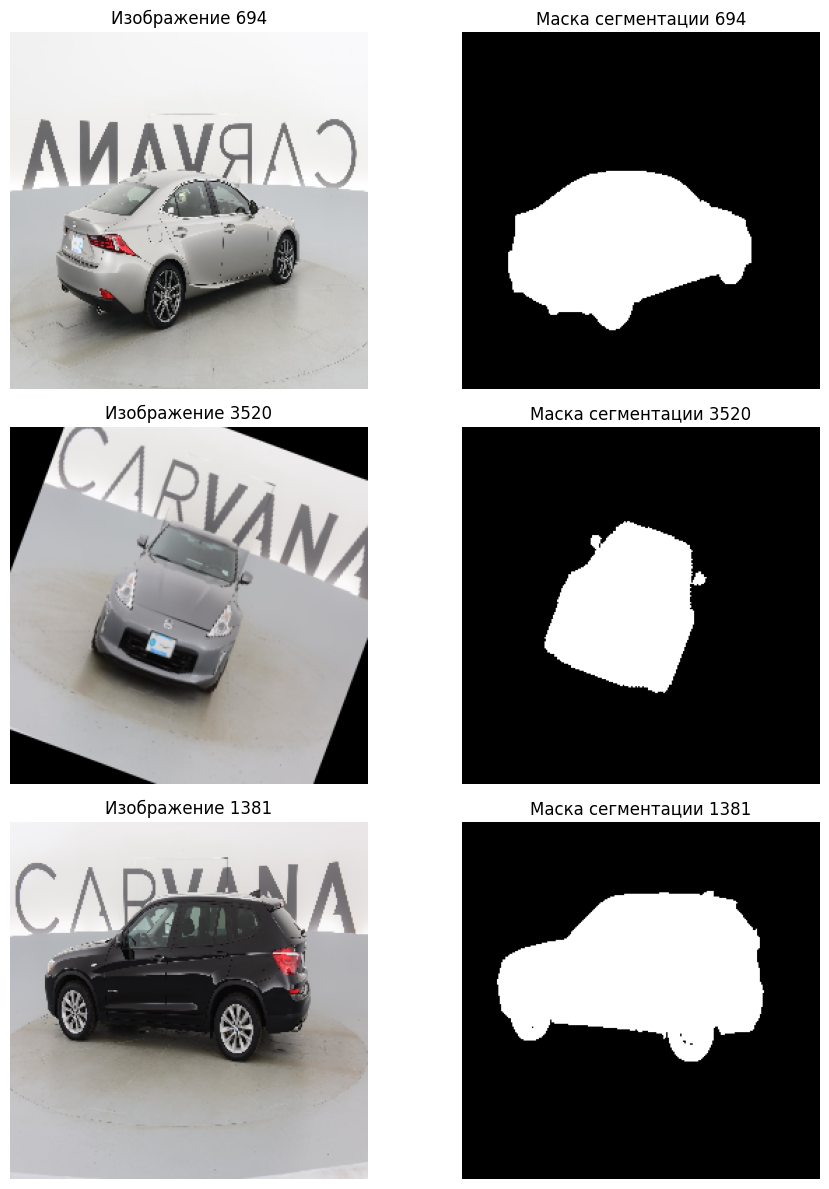

In [4]:
# Визуализация примеров из датасета
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4*num_samples))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        
        image_np = image.numpy().transpose(1, 2, 0)
        image_np = np.clip(image_np, 0, 1)
        
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title(f'Изображение {idx}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask.numpy(), cmap='gray')
        axes[i, 1].set_title(f'Маска сегментации {idx}')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, num_samples=3)

## Реализация архитектуры UNet

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    UNet архитектура для семантической сегментации
    """
    def __init__(self, in_channels=3, num_classes=20):
        super().__init__()
        
        # Encoder
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        # Decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        # Output
        self.outc = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder с сохранением промежуточных результатов
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder со skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Выходной слой
        logits = self.outc(x)
        return logits


# Создание модели
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'params num: {total_params:,}')

params num: 31,043,586


## Метрики качества: IoU и Dice

In [6]:
def calculate_iou(pred, target, num_classes, smooth=1e-6):
    """
    Вычисляет IoU (Intersection over Union) для каждого класса
    
    Args:
        pred: предсказания модели (batch_size, H, W)
        target: ground truth (batch_size, H, W)
        num_classes: количество классов
        smooth: сглаживающий коэффициент для избежания деления на 0
    
    Returns:
        mean_iou: средний IoU по всем классам
        iou_per_class: IoU для каждого класса
    """
    iou_list = []
    
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        
        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()
        
        if union == 0:
            iou = 1.0  # Если класса нет ни в pred, ни в target
        else:
            iou = (intersection + smooth) / (union + smooth)
        
        iou_list.append(iou.item())
    
    mean_iou = np.mean(iou_list)
    return mean_iou, iou_list


def calculate_dice(pred, target, num_classes, smooth=1e-6):
    """
    Вычисляет Dice Coefficient для каждого класса
    
    Args:
        pred: предсказания модели (batch_size, H, W)
        target: ground truth (batch_size, H, W)
        num_classes: количество классов
        smooth: сглаживающий коэффициент
    
    Returns:
        mean_dice: средний Dice по всем классам
        dice_per_class: Dice для каждого класса
    """
    dice_list = []
    
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        
        intersection = (pred_cls & target_cls).sum().float()
        pred_sum = pred_cls.sum().float()
        target_sum = target_cls.sum().float()
        
        if pred_sum + target_sum == 0:
            dice = 1.0
        else:
            dice = (2 * intersection + smooth) / (pred_sum + target_sum + smooth)
        
        dice_list.append(dice.item())
    
    mean_dice = np.mean(dice_list)
    return mean_dice, dice_list


def pixel_accuracy(pred, target):
    """
    Вычисляет pixel accuracy (для сравнения)
    """
    correct = (pred == target).sum().float()
    total = target.numel()
    return (correct / total).item()

## Обучение модели


In [7]:
# Параметры обучения
NUM_EPOCHS = 15
LEARNING_RATE = 0.001

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Обучение на одной эпохе"""
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    running_acc = 0.0
    
    pbar = tqdm(dataloader, desc='Обучение')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Метрики
        preds = torch.argmax(outputs, dim=1)
        iou, _ = calculate_iou(preds, masks, NUM_CLASSES)
        dice, _ = calculate_dice(preds, masks, NUM_CLASSES)
        acc = pixel_accuracy(preds, masks)
        
        running_loss += loss.item()
        running_iou += iou
        running_dice += dice
        running_acc += acc
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'IoU': f'{iou:.4f}',
            'Dice': f'{dice:.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_dice, epoch_acc


def validate(model, dataloader, criterion, device):
    """Валидация модели"""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Валидация'):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            preds = torch.argmax(outputs, dim=1)
            iou, _ = calculate_iou(preds, masks, NUM_CLASSES)
            dice, _ = calculate_dice(preds, masks, NUM_CLASSES)
            acc = pixel_accuracy(preds, masks)
            
            running_loss += loss.item()
            running_iou += iou
            running_dice += dice
            running_acc += acc
    
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_dice, epoch_acc

In [12]:
# История обучения
history = {
    'train_loss': [], 'train_iou': [], 'train_dice': [], 'train_acc': [],
    'val_loss': [], 'val_iou': [], 'val_dice': [], 'val_acc': []
}

best_val_iou = 0.0


for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 50)
    
    # Обучение
    train_loss, train_iou, train_dice, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Валидация
    val_loss, val_iou, val_dice, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Обновление learning rate
    scheduler.step(val_loss)
    
    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    history['val_acc'].append(val_acc)
    
    # Вывод результатов
    print(f'\nTrain   - Loss: {train_loss:.4f}, IoU: {train_iou:.4f}, Dice: {train_dice:.4f}, Acc: {train_acc:.4f}')
    print(f'Val  - Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, Dice: {val_dice:.4f}, Acc: {val_acc:.4f}')
    
    # Сохранение лучшей модели
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), 'best_unet_model.pth')
        print(f'Model saved (IoU: {best_val_iou:.4f})')
    
    print()

print(f'\nTraining complete! Best IoU: {best_val_iou:.4f}')

Epoch 1/15
--------------------------------------------------


Валидация: 100%|██████████| 255/255 [00:28<00:00,  8.89it/s]



Train   - Loss: 0.0248, IoU: 0.9720, Dice: 0.9857, Acc: 0.9905
Val  - Loss: 0.0153, IoU: 0.9826, Dice: 0.9912, Acc: 0.9941
Model saved (IoU: 0.9826)

Epoch 2/15
--------------------------------------------------


Валидация: 100%|██████████| 255/255 [00:29<00:00,  8.74it/s]



Train   - Loss: 0.0194, IoU: 0.9775, Dice: 0.9885, Acc: 0.9924
Val  - Loss: 0.0303, IoU: 0.9675, Dice: 0.9833, Acc: 0.9887

Epoch 3/15
--------------------------------------------------


...


Train   - Loss: 0.0109, IoU: 0.9866, Dice: 0.9932, Acc: 0.9955
Val  - Loss: 0.0094, IoU: 0.9885, Dice: 0.9942, Acc: 0.9961

Epoch 14/15
--------------------------------------------------


Валидация: 100%|██████████| 255/255 [00:28<00:00,  8.83it/s]



Train   - Loss: 0.0122, IoU: 0.9853, Dice: 0.9926, Acc: 0.9951
Val  - Loss: 0.0107, IoU: 0.9871, Dice: 0.9935, Acc: 0.9956

Epoch 15/15
--------------------------------------------------


Валидация: 100%|██████████| 255/255 [00:28<00:00,  8.86it/s]


Train   - Loss: 0.0122, IoU: 0.9853, Dice: 0.9926, Acc: 0.9951
Val  - Loss: 0.0097, IoU: 0.9880, Dice: 0.9940, Acc: 0.9960


Training complete! Best IoU: 0.9889


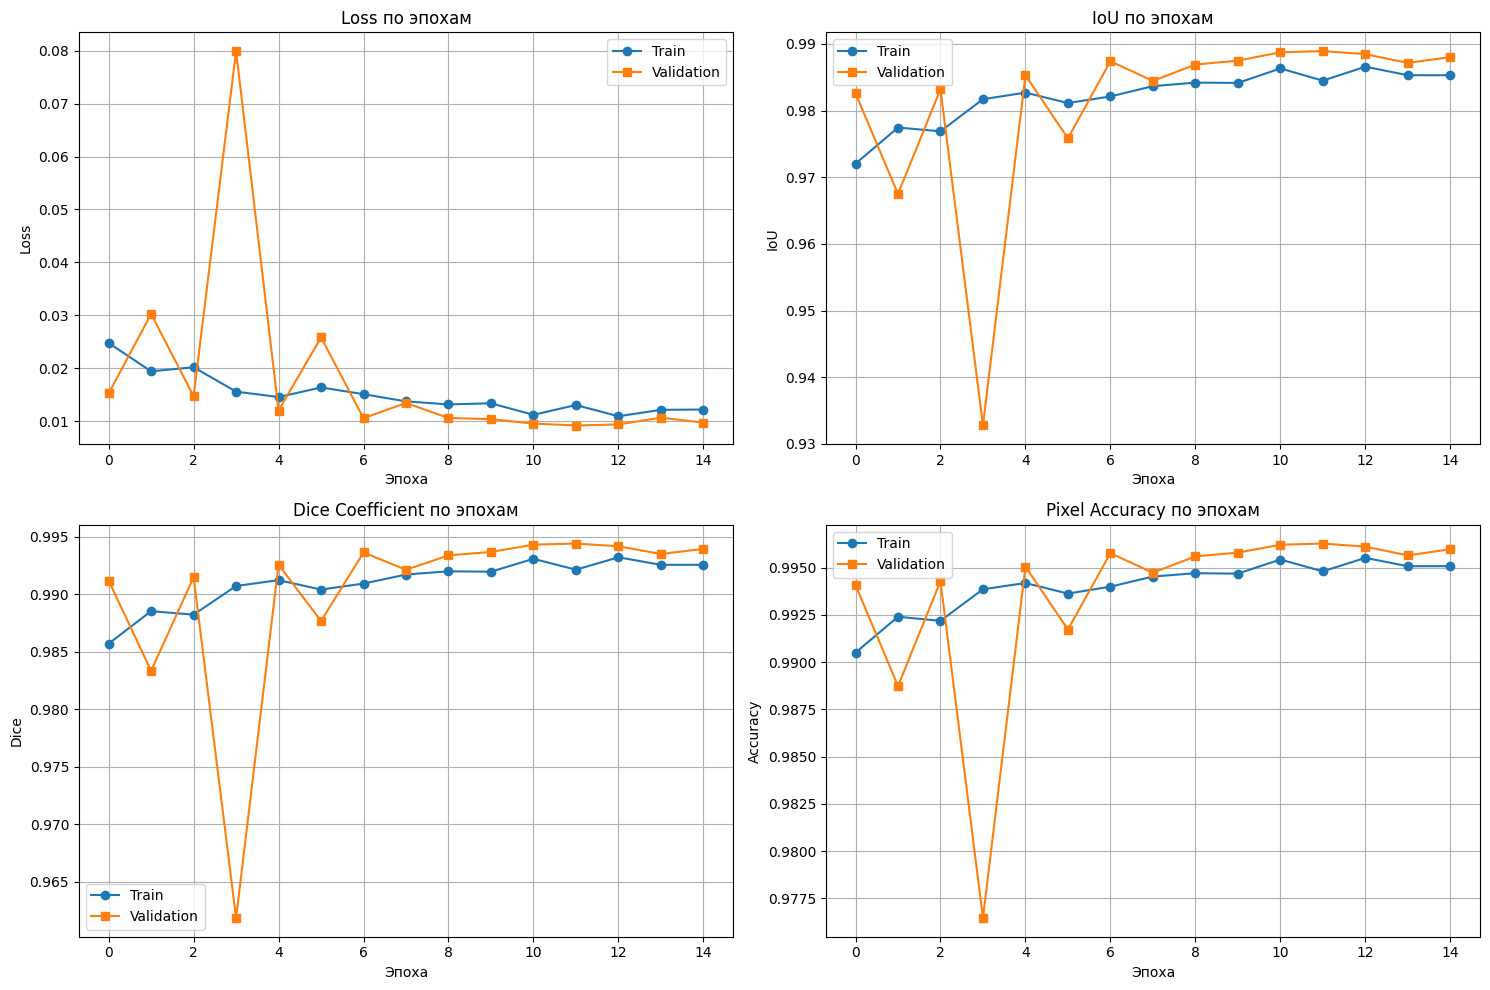

In [13]:
# Визуализация графиков обучения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o')
axes[0, 0].plot(history['val_loss'], label='Validation', marker='s')
axes[0, 0].set_title('Loss по эпохам')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# IoU
axes[0, 1].plot(history['train_iou'], label='Train', marker='o')
axes[0, 1].plot(history['val_iou'], label='Validation', marker='s')
axes[0, 1].set_title('IoU по эпохам')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Dice
axes[1, 0].plot(history['train_dice'], label='Train', marker='o')
axes[1, 0].plot(history['val_dice'], label='Validation', marker='s')
axes[1, 0].set_title('Dice Coefficient по эпохам')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Dice')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train', marker='o')
axes[1, 1].plot(history['val_acc'], label='Validation', marker='s')
axes[1, 1].set_title('Pixel Accuracy по эпохам')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## Визуализация результатов

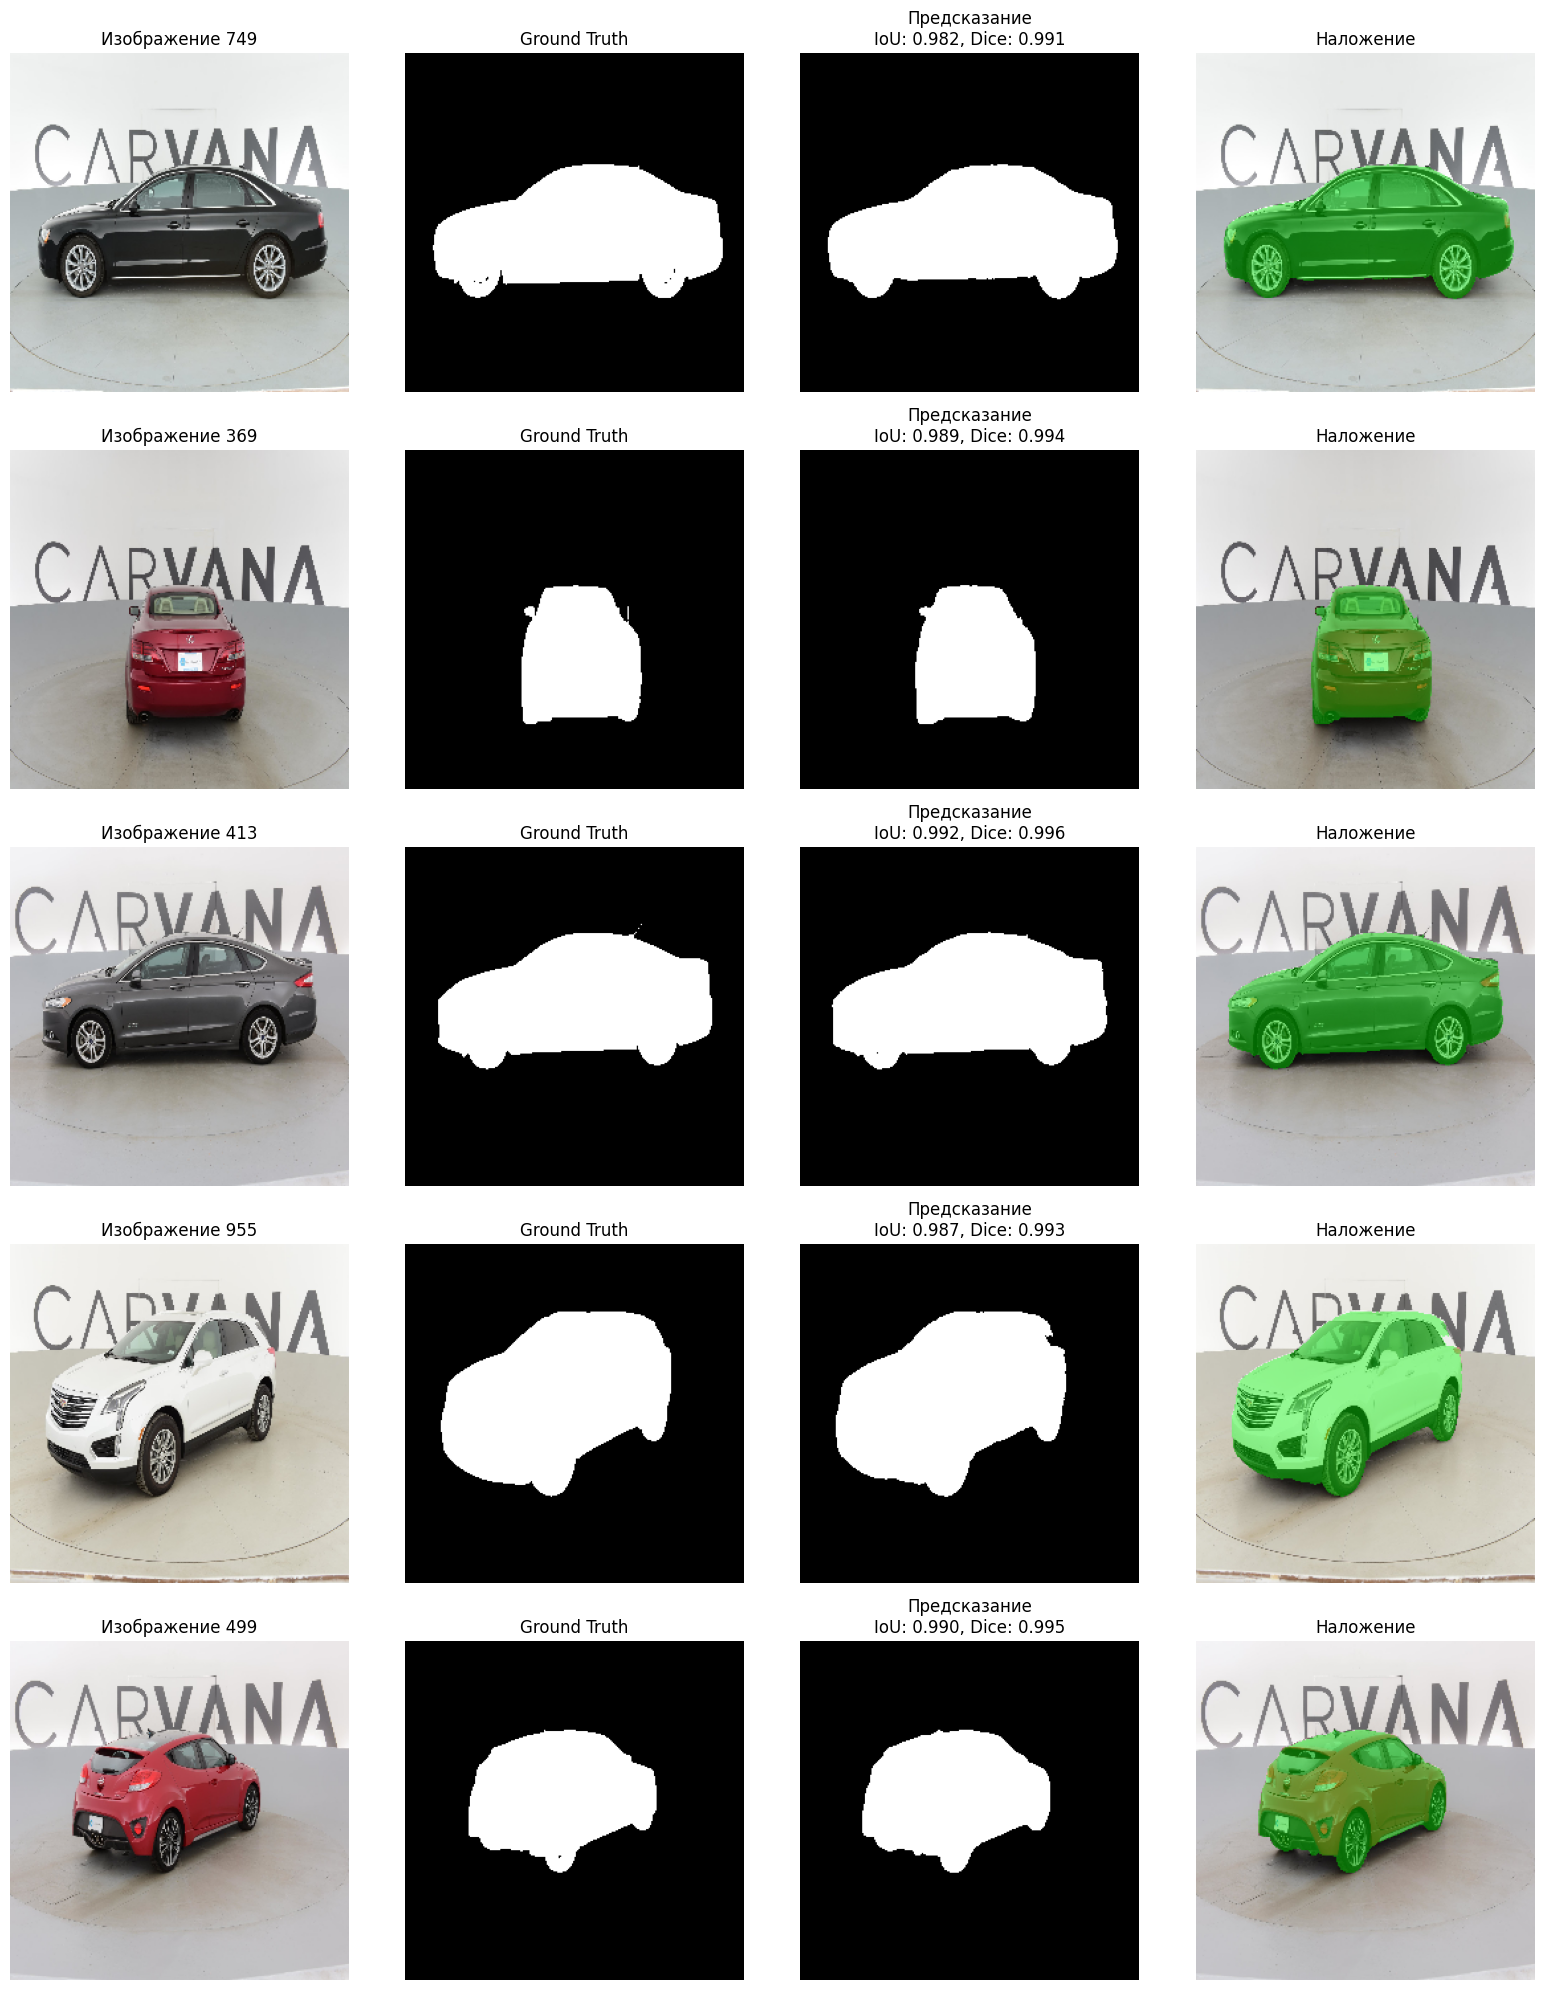

In [ ]:
def visualize_predictions(model, dataset, device, num_samples=5):
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    # Выбираем случайные индексы
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask_true = dataset[idx]
            
            # Предсказание
            image_input = image.unsqueeze(0).to(device)
            output = model(image_input)
            mask_pred = torch.argmax(output, dim=1).squeeze().cpu()
            
            # Денормализация изображения
            image_np = image.numpy().transpose(1, 2, 0)
            image_np = np.clip(image_np, 0, 1)
            
            # Вычисление метрик для этого изображения
            iou, _ = calculate_iou(mask_pred.unsqueeze(0), mask_true.unsqueeze(0), NUM_CLASSES)
            dice, _ = calculate_dice(mask_pred.unsqueeze(0), mask_true.unsqueeze(0), NUM_CLASSES)
            
            # Создание наложения предсказанной маски на изображение
            mask_pred_np = mask_pred.numpy()
            overlay = image_np.copy()
            
            # Маска (только класс 1 - автомобиль)
            mask_overlay = np.zeros_like(image_np)
            mask_overlay[:, :, 1] = mask_pred_np # зеленый канал
            
            # Наложение с прозрачностью там, где есть маска
            mask_indices = mask_pred_np > 0
            overlay[mask_indices] = 0.6 * overlay[mask_indices] + 0.4 * mask_overlay[mask_indices]
            
            # Отображение
            axes[i, 0].imshow(image_np)
            axes[i, 0].set_title(f'Изображение {idx}')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_true.numpy(), cmap='gray')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(mask_pred_np, cmap='gray')
            axes[i, 2].set_title(f'Предсказание\nIoU: {iou:.3f}, Dice: {dice:.3f}')
            axes[i, 2].axis('off')
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Наложение')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

if os.path.exists('best_unet_model.pth'):
    model.load_state_dict(torch.load('best_unet_model.pth'))
    # Визуализация на валидационной выборке
    visualize_predictions(model, val_dataset, device, num_samples=5)

In [ ]:
print("Детальная оценка качества по классам")
print("=" * 40)

model.eval()
all_iou = []
all_dice = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        _, iou_per_class = calculate_iou(preds, masks, NUM_CLASSES)
        _, dice_per_class = calculate_dice(preds, masks, NUM_CLASSES)
        
        all_iou.append(iou_per_class)
        all_dice.append(dice_per_class)

# Усреднение по батчам
avg_iou = np.mean(all_iou, axis=0)
avg_dice = np.mean(all_dice, axis=0)

class_names = {
    0: 'Фон', 1: 'Автомобиль'
}

print(f"{'Класс':<15} {'IoU':>10} {'Dice':>10}")
print("-" * 40)
for cls in [0, 1]:
    name = class_names.get(cls, f'Класс {cls}')
    print(f"{name:<15} {avg_iou[cls]:>10.4f} {avg_dice[cls]:>10.4f}")

print("-" * 40)
print(f"{'Mean IoU':<15} {np.mean(avg_iou):>10.4f}")
print(f"{'Mean Dice':<15} {np.mean(avg_dice):>10.4f}")

Детальная оценка качества по классам
Класс                  IoU       Dice
----------------------------------------
Фон                 0.9952     0.9976
Автомобиль          0.9827     0.9912
----------------------------------------
Mean IoU            0.9889
Mean Dice           0.9944


## Эксперименты

### Эксперимент: Другие размеры входных изображений

In [16]:
# Эксперимент с размером 128x128
print("Эксперимент: Обучение с размером изображения 128x128")
print("=" * 60)

IMG_SIZE_EXP = 128
NUM_EPOCHS_EXP = 10

# Создание датасетов меньшего размера
train_dataset_small = CarvanaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_files, transform=A.Compose([
    A.Resize(IMG_SIZE_EXP, IMG_SIZE_EXP),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
]))

val_dataset_small = CarvanaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, val_files, transform=A.Compose([
    A.Resize(IMG_SIZE_EXP, IMG_SIZE_EXP),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
]))

train_loader_small = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader_small = DataLoader(val_dataset_small, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Создание новой модели
model_small = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
criterion_small = nn.CrossEntropyLoss()
optimizer_small = optim.Adam(model_small.parameters(), lr=LEARNING_RATE)

# История для маленькой модели
history_small = {'train_iou': [], 'val_iou': [], 'train_dice': [], 'val_dice': []}

# Обучение
for epoch in range(NUM_EPOCHS_EXP):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS_EXP}', end=' - ')
    
    train_loss, train_iou, train_dice, _ = train_epoch(
        model_small, train_loader_small, criterion_small, optimizer_small, device
    )
    val_loss, val_iou, val_dice, _ = validate(
        model_small, val_loader_small, criterion_small, device
    )
    
    history_small['train_iou'].append(train_iou)
    history_small['val_iou'].append(val_iou)
    history_small['train_dice'].append(train_dice)
    history_small['val_dice'].append(val_dice)
    
    print(f'Val IoU: {val_iou:.4f}, Val Dice: {val_dice:.4f}')

print(f"\nРезультаты эксперимента:")
print(f"  Размер 256x256: Val IoU = {max(history['val_iou']):.4f}, Val Dice = {max(history['val_dice']):.4f}")
print(f"  Размер 128x128: Val IoU = {max(history_small['val_iou']):.4f}, Val Dice = {max(history_small['val_dice']):.4f}")
print("=" * 60)

Эксперимент: Обучение с размером изображения 128x128
Epoch 1/10 - 

Валидация: 100%|██████████| 255/255 [00:23<00:00, 10.86it/s]


Val IoU: 0.9702, Val Dice: 0.9848
Epoch 2/10 - 

Валидация: 100%|██████████| 255/255 [00:23<00:00, 10.99it/s]


Val IoU: 0.9229, Val Dice: 0.9592
Epoch 3/10 - 

...

Val IoU: 0.9827, Val Dice: 0.9912
Epoch 9/10 - 

Валидация: 100%|██████████| 255/255 [00:23<00:00, 10.92it/s]


Val IoU: 0.9802, Val Dice: 0.9899
Epoch 10/10 - 

Валидация: 100%|██████████| 255/255 [00:23<00:00, 10.66it/s]

Val IoU: 0.9835, Val Dice: 0.9917

Результаты эксперимента:
  Размер 256x256: Val IoU = 0.9889, Val Dice = 0.9944
  Размер 128x128: Val IoU = 0.9835, Val Dice = 0.9917


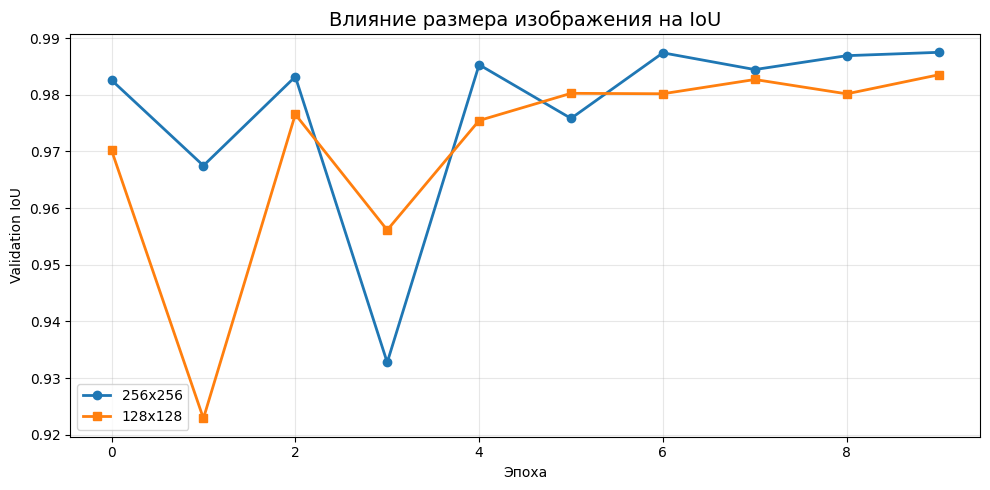

In [26]:
# Сравнительная визуализация результатов экспериментов
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# Сравнение по размерам
axes.plot(history['val_iou'][:NUM_EPOCHS_EXP], label='256x256', marker='o', linewidth=2)
axes.plot(history_small['val_iou'], label='128x128', marker='s', linewidth=2)
axes.set_title('Влияние размера изображения на IoU', fontsize=14)
axes.set_xlabel('Эпоха')
axes.set_ylabel('Validation IoU')
axes.legend()
axes.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Эксперимент: Аугментация


In [23]:
print("Эксперимент: Обучение БЕЗ аугментаций")
print("=" * 60)

# Создание датасета без аугментаций
train_dataset_no_aug = CarvanaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_files, transform=A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
]))

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

# Создание новой модели
model_no_aug = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
criterion_no_aug = nn.CrossEntropyLoss()
optimizer_no_aug = optim.Adam(model_no_aug.parameters(), lr=LEARNING_RATE)

# История
history_no_aug = {'train_iou': [], 'val_iou': [], 'train_dice': [], 'val_dice': []}

# Обучение (меньше эпох для демонстрации)
for epoch in range(NUM_EPOCHS_EXP):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS_EXP}', end=' - ')
    
    train_loss, train_iou, train_dice, _ = train_epoch(
        model_no_aug, train_loader_no_aug, criterion_no_aug, optimizer_no_aug, device
    )
    val_loss, val_iou, val_dice, _ = validate(
        model_no_aug, val_loader, criterion_no_aug, device
    )
    
    history_no_aug['train_iou'].append(train_iou)
    history_no_aug['val_iou'].append(val_iou)
    history_no_aug['train_dice'].append(train_dice)
    history_no_aug['val_dice'].append(val_dice)
    
    print(f'Val IoU: {val_iou:.4f}, Val Dice: {val_dice:.4f}')

print(f"\nСравнение результатов:")
print(f"  С аугментациями:    Val IoU = {max(history['val_iou']):.4f}, Val Dice = {max(history['val_dice']):.4f}")
print(f"  Без аугментаций:    Val IoU = {max(history_no_aug['val_iou']):.4f}, Val Dice = {max(history_no_aug['val_dice']):.4f}")
print("=" * 60)

Эксперимент: Обучение БЕЗ аугментаций
Epoch 1/10 - 

Валидация: 100%|██████████| 255/255 [00:27<00:00,  9.34it/s]


Val IoU: 0.9335, Val Dice: 0.9641
Epoch 2/10 - 

Валидация: 100%|██████████| 255/255 [00:29<00:00,  8.78it/s]


Val IoU: 0.5743, Val Dice: 0.7185
Epoch 3/10 - 

...

Val IoU: 0.9841, Val Dice: 0.9919
Epoch 9/10 - 

Валидация: 100%|██████████| 255/255 [00:27<00:00,  9.11it/s]


Val IoU: 0.9909, Val Dice: 0.9954
Epoch 10/10 - 

Валидация: 100%|██████████| 255/255 [00:28<00:00,  8.80it/s]

Val IoU: 0.9908, Val Dice: 0.9954

Сравнение результатов:
  С аугментациями:    Val IoU = 0.9889, Val Dice = 0.9944
  Без аугментаций:    Val IoU = 0.9909, Val Dice = 0.9954


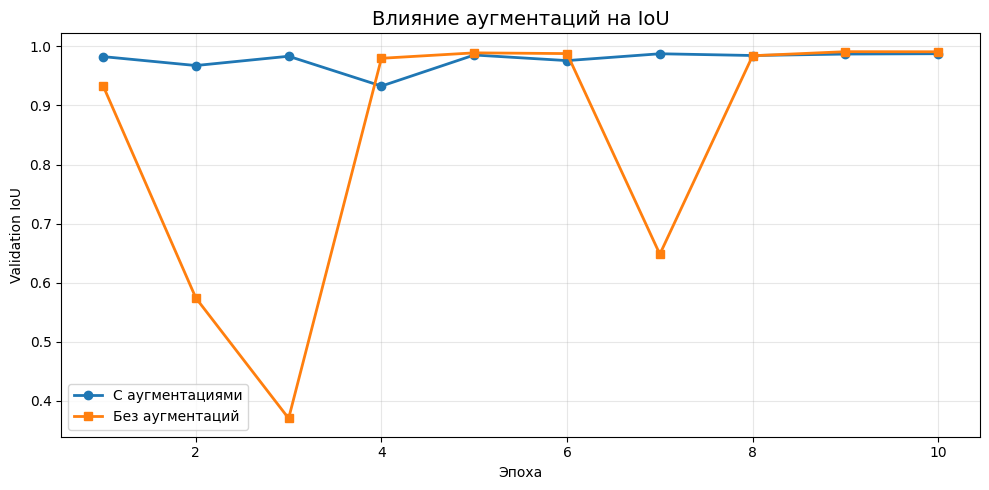

In [24]:
# Сравнительная визуализация результатов экспериментов
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# # Сравнение аугментаций
epochs_aug = range(1, len(history['val_iou'][:NUM_EPOCHS_EXP]) + 1)
axes.plot(epochs_aug, history['val_iou'][:NUM_EPOCHS_EXP], label='С аугментациями', marker='o', linewidth=2)
axes.plot(epochs_aug, history_no_aug['val_iou'], label='Без аугментаций', marker='s', linewidth=2)
axes.set_title('Влияние аугментаций на IoU', fontsize=14)
axes.set_xlabel('Эпоха')
axes.set_ylabel('Validation IoU')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:

# Итоговая таблица результатов
print(f"{'Конфигурация':<35} {'Max Val IoU':>15} {'Max Val Dice':>15}")
print("-" * 70)
print(f"{'Базовая модель (256x256, с aug)':<35} {max(history['val_iou']):>15.4f} {max(history['val_dice']):>15.4f}")
print(f"{'Меньший размер (128x128, с aug)':<35} {max(history_small['val_iou']):>15.4f} {max(history_small['val_dice']):>15.4f}")
print(f"{'Без аугментаций (256x256)':<35} {max(history_no_aug['val_iou']):>15.4f} {max(history_no_aug['val_dice']):>15.4f}")

Конфигурация                            Max Val IoU    Max Val Dice
----------------------------------------------------------------------
Базовая модель (256x256, с aug)              0.9889          0.9944
Меньший размер (128x128, с aug)              0.9835          0.9917
Без аугментаций (256x256)                    0.9909          0.9954


## Ответы на контрольные вопросы

### Вопрос 1: Почему accuracy плохо отражает качество сегментации?

1. Дисбаланс классов: В большинстве задач сегментации классы распределены неравномерно. Например, в городских сценах фон, небо и дорога могут занимать 90% изображения, а важные объекты (пешеходы, автомобили) — всего 10%. Модель может просто предсказывать фоновый класс везде и получить 90% accuracy, но при этом полностью провалить задачу по сегментации важных объектов.

2. Не учитывает пространственную структуру: Accuracy считает только количество правильно классифицированных пикселей, игнорируя, насколько хорошо сохранены границы объектов и их форма. Модель может правильно определить класс большинства пикселей, но полностью испортить контуры объектов.


### Вопрос 2: Чем UNet отличается от "обычной" CNN?

UNet — это специализированная архитектура для задач семантической сегментации, которая имеет ключевые отличия от "обычных" CNN (таких как VGG, ResNet для классификации):

#### U-образная архитектура с Encoder-Decoder структурой

- Обычная CNN: Имеет только encoder (кодировщик) — последовательность сверточных и pooling слоев, которые уменьшают размерность и увеличивают количество каналов. Выход — вектор фиксированной длины для классификации.

- UNet: Состоит из двух частей:
  - Encoder (левая часть U): Уменьшает пространственное разрешение (как в обычной CNN)
  - Decoder (правая часть U): Увеличивает разрешение обратно до размера входного изображения через upsampling/transpose convolutions

#### Skip Connections 

- Обычная CNN: Информация проходит только в прямом направлении, теряя детали на каждом pooling слое.

- UNet: Использует skip connections — прямые связи между соответствующими слоями encoder и decoder: копирует feature maps из encoder напрямую в decoder, что позволяет восстановить мелкие детали и точные границы объектов.

#### Выходной формат

- Обычная CNN: Выход — вектор вероятностей для классов (например, [0.1, 0.7, 0.2] для 3 классов)

- UNet: Выход — матрица размером (`num_classes`, `H`, `W`), где для каждого пикселя предсказывается класс.